# Bank Marketing Funnel & Conversion Analysis
This data is from a bank's phone marketing campaign selling term deposits.
The funnel here is: **Lead contacted -> Call connected -> Customer converts (subscribes)**.
We'll find where conversion is highest, which channels and segments work best, and what to fix.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("bank-additional-full.csv", sep=';')
df.shape

(41188, 21)

## 1. Clean the data

In [2]:
# strip any stray quotes/spaces from text columns
str_cols = df.select_dtypes(include='object').columns
for c in str_cols:
    df[c] = df[c].str.strip()

df['Converted'] = (df['y'] == 'yes').astype(int)

print("Rows:", len(df))
df.head()

Rows: 41188


/tmp/ipykernel_573/389714447.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_cols = df.select_dtypes(include='object').columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,Converted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


## 2. The funnel: leads -> connected -> converted

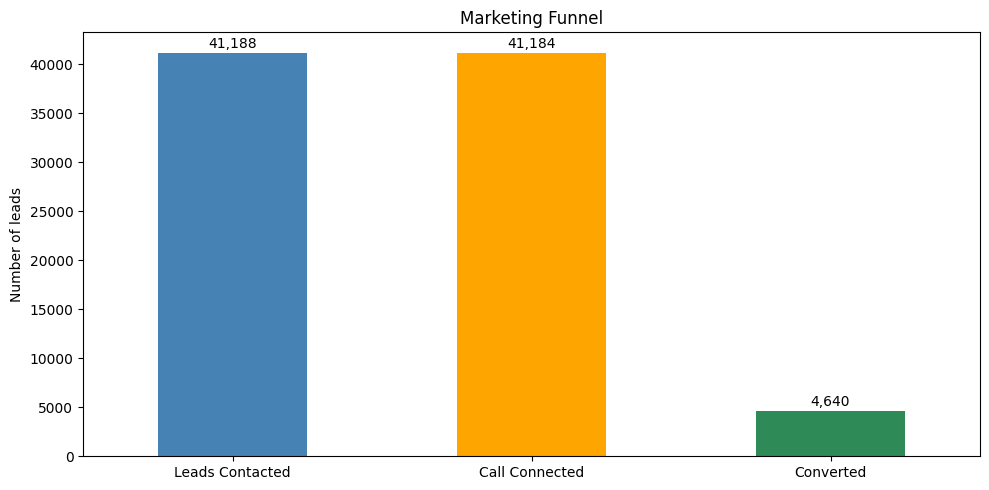

Overall conversion rate: 11.3%


In [3]:
total_leads = len(df)
connected = (df['duration'] > 0).sum()
converted = df['Converted'].sum()

funnel = pd.Series({
    'Leads Contacted': total_leads,
    'Call Connected': connected,
    'Converted': converted
})

ax = funnel.plot(kind='bar', color=['steelblue','orange','seagreen'])
ax.set_title("Marketing Funnel")
ax.set_ylabel("Number of leads")
for i, v in enumerate(funnel):
    ax.text(i, v + 500, f"{v:,}", ha='center')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Overall conversion rate: {converted/total_leads:.1%}")

## 3. Conversion by number of contact attempts
Does calling someone more times help, or does it wear people out?

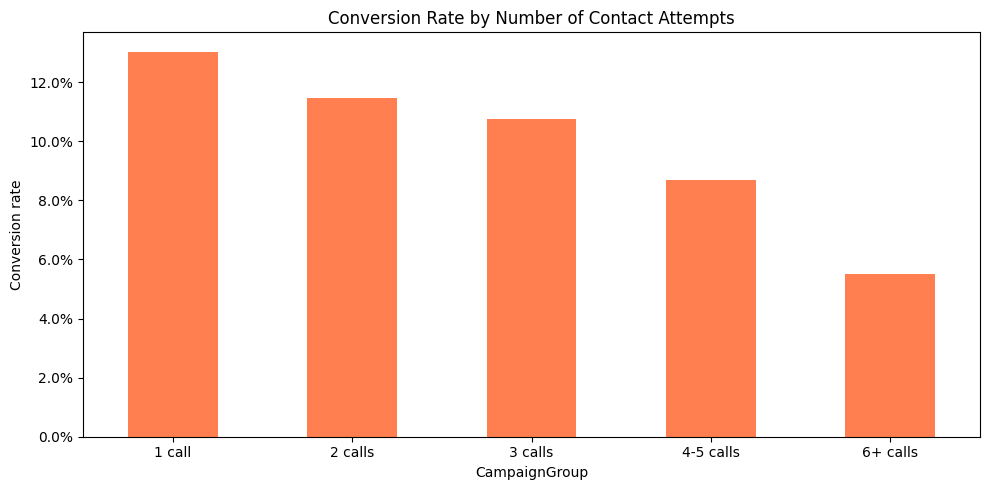

CampaignGroup
1 call       0.130371
2 calls      0.114570
3 calls      0.107471
4-5 calls    0.086824
6+ calls     0.054948
Name: Converted, dtype: float64

In [4]:
df['CampaignGroup'] = pd.cut(df['campaign'], bins=[0,1,2,3,5,60],
                             labels=['1 call','2 calls','3 calls','4-5 calls','6+ calls'])

attempt_conv = df.groupby('CampaignGroup')['Converted'].mean()

ax = attempt_conv.plot(kind='bar', color='coral')
ax.set_title("Conversion Rate by Number of Contact Attempts")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

attempt_conv

## 4. Conversion by channel
Cellular vs landline telephone.

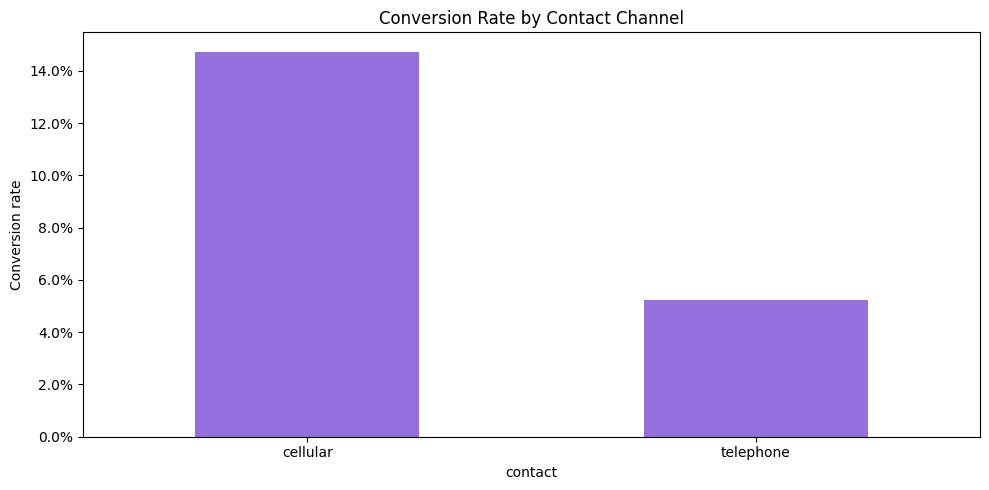

contact
cellular     0.147376
telephone    0.052313
Name: Converted, dtype: float64

In [5]:
channel_conv = df.groupby('contact')['Converted'].mean().sort_values(ascending=False)

ax = channel_conv.plot(kind='bar', color='mediumpurple')
ax.set_title("Conversion Rate by Contact Channel")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

channel_conv

## 5. Does past contact help?
poutcome = result of the previous marketing campaign for this lead.

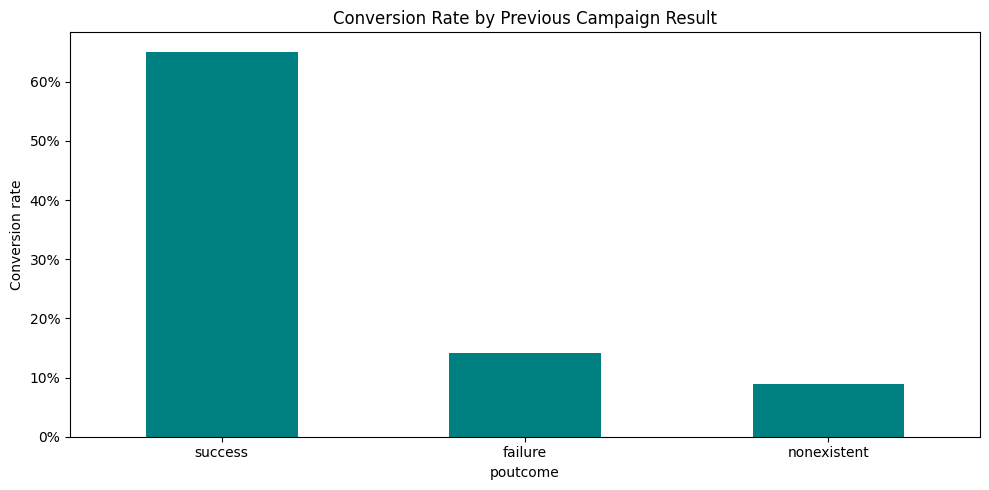

poutcome
success        0.651129
failure        0.142286
nonexistent    0.088322
Name: Converted, dtype: float64

In [6]:
past_conv = df.groupby('poutcome')['Converted'].mean().sort_values(ascending=False)

ax = past_conv.plot(kind='bar', color='teal')
ax.set_title("Conversion Rate by Previous Campaign Result")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

past_conv

## 6. Conversion over the year
By month, to see seasonality.

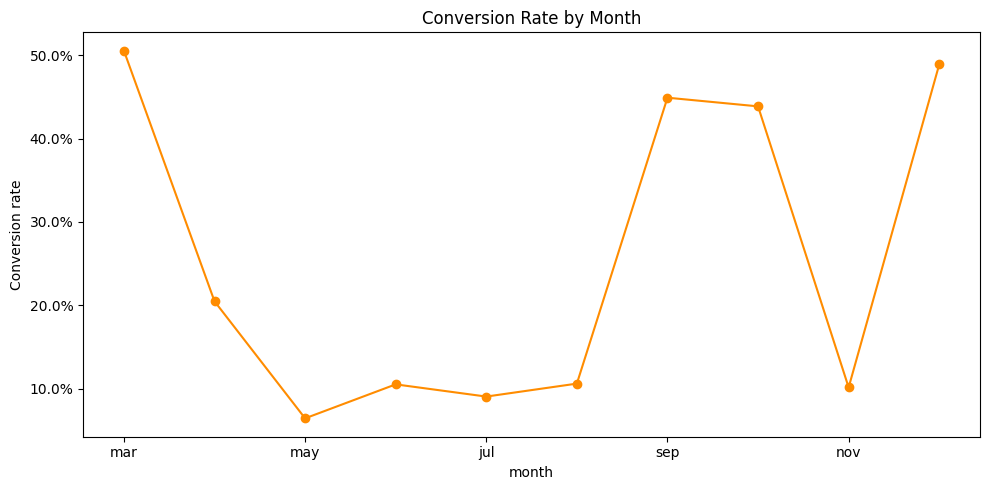

In [7]:
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_conv = df.groupby('month')['Converted'].mean().reindex(month_order).dropna()

ax = month_conv.plot(marker='o', color='darkorange')
ax.set_title("Conversion Rate by Month")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

## 7. Conversion by customer segment
Job type and age group.

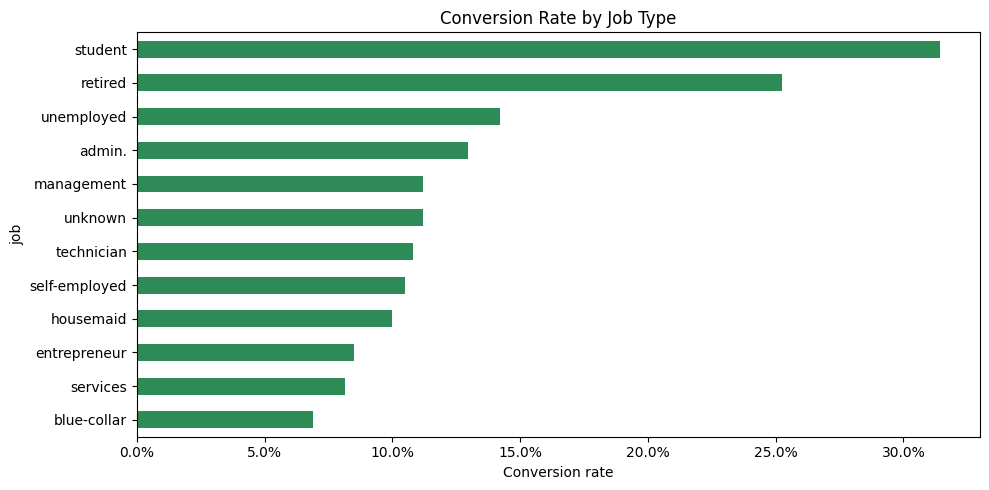

In [8]:
job_conv = df.groupby('job')['Converted'].mean().sort_values(ascending=False)

ax = job_conv.sort_values().plot(kind='barh', color='seagreen')
ax.set_title("Conversion Rate by Job Type")
ax.set_xlabel("Conversion rate")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

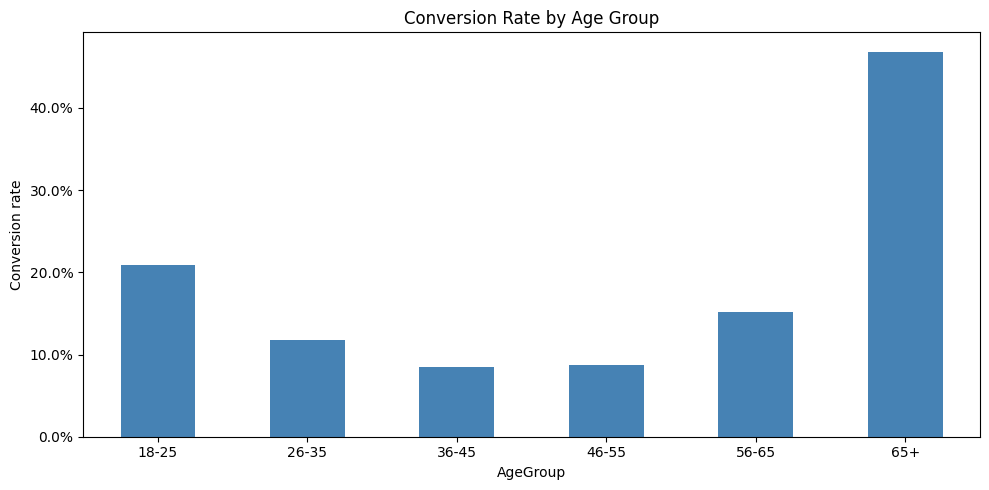

In [9]:
df['AgeGroup'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,100],
                        labels=['18-25','26-35','36-45','46-55','56-65','65+'])

age_conv = df.groupby('AgeGroup', observed=True)['Converted'].mean()

ax = age_conv.plot(kind='bar', color='steelblue')
ax.set_title("Conversion Rate by Age Group")
ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Note on call duration
Longer calls almost always convert better in this data, but that's expected — a call can only run long if the person keeps talking, and people who are interested talk longer. Duration is only known *after* the call ends, so it can't be used to decide who to call. We leave it out of the recommendations for that reason.

## 9. Insights & recommendations

**What we found:**
- Overall conversion rate is **~11.3%** — about 1 in 9 leads become customers.
- **More calls to the same lead does not help.** Conversion is highest on the **first call** and drops steadily the more times someone is called. Past 6 calls, conversion is very low.
- **Cellular numbers convert much better than landline (telephone)** contacts.
- **Leads who said yes to a past campaign convert at a very high rate** — far higher than new leads or leads who said no before.
- Conversion is **much higher in March, September, October, and December** than in the summer months (May-August), suggesting timing matters a lot.
- **Retired and student segments convert best**, blue-collar and services convert worst.
- The **youngest (18-25) and oldest (65+) age groups convert far better** than the working-age middle (26-55). 65+ converts almost 5x the overall average.

**What the business should do:**
1. **Cap contact attempts at 2-3 calls per lead.** Calling more than that wastes time and can annoy leads without adding conversions.
2. **Prioritize cellular numbers** when a lead has both a cellphone and landline on file.
3. **Build a "past responders" list.** Leads with a past successful campaign should be called first — they convert far above average.
4. **Shift campaign timing** away from summer months and toward March, September, October, December.
5. **Target retirees, students, and both very young and older customers** with tailored messaging, since they respond best. Consider a different pitch or offer for the working-age middle segment and blue-collar/services jobs instead of the same script.
6. **Use these funnel stages as a dashboard** (leads called -> connected -> converted) to track week-over-week performance and catch drop-offs early.
